# CSMODEL Project - Netflix Userbase Dataset Case Study

### Group 8
CAPAROS, MIGUEL ANTONIO <br> 
FERRER, ANGEL JUNE <br>
MARTINEZ, AZELIAH <br>
VILLANUEVA, KEISHA LEIGH <br>

# PHASE 1


# I. Dataset Description

In this section of the notebook, we provide a comprehensive overview of the dataset used for our analysis. The dataset chosen for this project is the Netflix Userbase Dataset, which provides a synthetic snapshot of a sample Netflix userbase. 

## Dataset Overview

The Netflix Userbase Dataset represent a broad range of user information which includes various details about user subscriptions, revenue, account details, and activity.

## Data Collection Process

The dataset is synthetically sourced, meaning it is generated to mimic real-world data without reflecting actual Netflix user information. This method allows for privacy preservation but also implies that any conclusions drawn from the dataset may not accurately reflect real-world user behavior or trends.

## Dataset File Structure

Each row in the dataset represents a unique user while each column contain various details about the user. The dataset contains a total of 2500 observations (rows) and 10 variables (columns). Each variable provides specific details about the users, enabling analysis of subscription patterns, revenue generation, and user behavior.

## Dataset Variables

The dataset contains 10 variables, each representing different user information such as:

| Variable             | Description                                                                                   |
|--------------------|-----------------------------------------------------------------------------------------------|
| User ID            | A unique identifier for each user.                                                             |
| Subscription Type  | The type of subscription the user has (basic, standard, or premium).                            |
| Monthly Revenue    | The monthly revenue generated from the user's subscription.                                     |
| Join Date          | The date the user joined Netflix.                                                              |
| Last Payment Date  | The date of the user's last payment.                                                          |
| Country            | The country where the user is located.                                                         |
| Age                | The age of the user.                                                                           |
| Gender             | The gender of the user.                                                                        |
| Device Type        | The type of device the user primarily uses to access Netflix (e.g., Smart TV, Mobile, Desktop, Tablet). |
| Plan Duration      | The duration of the user's current subscription plan.                                           |


# II. Data Cleaning

In this section of the notebook, we will focus on cleaning the Netflix Userbase Dataset. Data cleaning is an essential step in the data analysis process, aimed at preparing raw data for further exploration and analysis. It involves identifying and correcting errors or inconsistencies in the data, handling missing values, removing duplicates, and ensuring data quality and integrity.

## Import Libraries

We begin by importing essential libraries for data manipulation, analysis, and visualization. **`numpy`** and **`pandas`** are fundamental for numerical operations and data manipulation tasks, offering efficient array handling and DataFrame operations, respectively. clustering_analysis includes custom functions for aggregation, K-means clustering, and visualization, tailored to our specific analytical needs. Importing **`chi2_contingency`** from **`scipy.stats`** facilitates statistical tests like chi-square analysis. **`matplotlib.pyplot`** enables us to create diverse visualizations, while **`seaborn`** enhances these plots with improved aesthetics and additional statistical capabilities.

In [1]:
# Initial import to prevent memory leaks in certain functions
import os
os.environ["OMP_NUM_THREADS"] = "1"     # Limits the number of threads to prevent memory leaks in some functions

In [2]:
# Data Manipulation 
import numpy as np                       # For numerical operations
import pandas as pd                      # For data manipulation and analysis
import clustering_analysis as ca         # File containing functions for aggregation, K-means clustering, and visualization
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency # For performing statistical tests, specifically chi-square tests

# Visualization
import matplotlib.pyplot as plt     # For creating plots and visualizations
import seaborn as sns               # For enhancing visualizations


## Reading the Dataset

Our first step is to load the dataset using pandas, which will import the data into a pandas `DataFrame`. We use the [`read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) function to accomplish this.

In [3]:
userbase_df = pd.read_csv('Netflix Userbase.csv')

When loading a new dataset, it is advisable to utilize the [`info`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html) function, as it displays general information regarding the dataset's structure and attributes.

In [4]:
userbase_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   User ID            2500 non-null   int64 
 1   Subscription Type  2500 non-null   object
 2   Monthly Revenue    2500 non-null   int64 
 3   Join Date          2500 non-null   object
 4   Last Payment Date  2500 non-null   object
 5   Country            2500 non-null   object
 6   Age                2500 non-null   int64 
 7   Gender             2500 non-null   object
 8   Device             2500 non-null   object
 9   Plan Duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


We will use the [`head`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html) function to quickly view the first few rows of our dataset.

In [5]:
userbase_df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


## Handling Missing Data

Detecting and managing missing values is crucial for data analysis. To identify missing data within our DataFrame, we will use the [`isnull`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isnull.html) function in combination with [`sum`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isnull.html). This approach allows us to understand the extent of missing values in each column, facilitating appropriate strategies for data cleaning and preprocessing.

In [6]:
missing_data = userbase_df.isnull().sum()
print("Missing data:\n", missing_data)

Missing data:
 User ID              0
Subscription Type    0
Monthly Revenue      0
Join Date            0
Last Payment Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan Duration        0
dtype: int64


## Duplicate Handling

Duplicates in datasets can impact the accuracy of analysis results and should be managed to ensure data integrity. Identifying and managing duplicates is an essential step in data preprocessing. We use the [`duplicated`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) function to find rows that are exact duplicates based on specified columns (`subset`). For instance, we will check for duplicates based on 'Country' and 'Subscription Type'. If duplicates are identified (`not duplicate_rows.empty`), they are displayed for further examination. Otherwise, a message indicating no duplicates are found is shown.

This code snippet identifies and prints duplicate rows in the dataset that have the same values in the 'Country' column. The `duplicated()` function with `keep=False` ensures all occurrences of duplicates are highlighted.

In [7]:
# Find duplicated rows based on 'Country' and 'Subscription Type'
duplicate_rows = userbase_df[userbase_df.duplicated(subset=['Country', 'Subscription Type'], keep=False)]

if not duplicate_rows.empty:
    print("\nNumber of duplicated rows:", len(duplicate_rows))

    # Count the number of unique combinations
    unique_combinations = duplicate_rows.groupby(['Country', 'Subscription Type']).size().reset_index(name='Count')

    print("Number of unique combinations:", len(unique_combinations))
    print("\nUnique combinations based on 'Country' and 'Subscription Type':")
    print(unique_combinations)
else:
    print("No duplicate rows found based on 'Country' and 'Subscription Type'.")



Number of duplicated rows: 2500
Number of unique combinations: 27

Unique combinations based on 'Country' and 'Subscription Type':
           Country Subscription Type  Count
0        Australia             Basic     31
1        Australia           Premium    101
2        Australia          Standard     51
3           Brazil             Basic    146
4           Brazil           Premium     33
5           Brazil          Standard      4
6           Canada             Basic    145
7           Canada           Premium     88
8           Canada          Standard     84
9           France             Basic     36
10          France           Premium    147
11         Germany             Basic    149
12         Germany           Premium      3
13         Germany          Standard     31
14           Italy             Basic    176
15           Italy           Premium      4
16           Italy          Standard      3
17          Mexico             Basic      4
18          Mexico          Stan

## Handling Inconsistent Formatting

Inconsistent formatting in a dataset can cause errors in analysis and lead to misinterpreted results. Different representations of the same data, such as variations in text case ('United States', 'united States', 'UNITED STATES') or inconsistent date formats, can be mistakenly treated as different values. This can distort analysis outcomes and produce inaccurate conclusions. By standardizing data formats, we ensure uniformity, which allows for accurate comparisons and aggregations. This consistency is essential for reliable data analysis and modeling.

To address this, let's standardize the 'Country' and 'Subscription Type' columns to lowercase. Using [`str.lower`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.lower.html) function, it converts all entries in the 'Country' and 'Subscription Type' columns to lowercase, ensuring consistency. The [`unique`](https://pandas.pydata.org/docs/reference/api/pandas.Series.unique.html) function is then used to display all unique values in the column after the transformation, allowing us to verify that the standardization was successful.

In [8]:
userbase_df['Country'] = userbase_df['Country'].str.lower()
userbase_df['Subscription Type'] = userbase_df['Subscription Type'].str.lower()


print("Unique values after converting 'Country' to lowercase:")
print(userbase_df['Country'].unique())
print("\n")

print("Unique values after converting 'Subscription Type' to lowercase:")
print(userbase_df['Subscription Type'].unique())
print("\n")

Unique values after converting 'Country' to lowercase:
['united states' 'canada' 'united kingdom' 'australia' 'germany' 'france'
 'brazil' 'mexico' 'spain' 'italy']


Unique values after converting 'Subscription Type' to lowercase:
['basic' 'premium' 'standard']




# III. Exploratory Data Analysis

In this section of the notebook, we aim to explore and understand various aspects of the Netflix Userbase Dataset through exploratory data analysis. 

## Univariate Analysis

This analysis provides comprehensive statistical summaries for both numerical and categorical features within the Netflix userbase dataset. It highlights key metrics such as mean, median, and standard deviation for numerical variables, alongside insights into the distribution and frequency of categorical variables, offering a detailed understanding of the dataset's characteristics.

In [9]:
# Describing all the Numerical Features
userbase_df.describe()

,User ID,Monthly Revenue,Age
count,2500.00000,2500.000000,2500.000000
mean,1250.50000,12.508400,38.795600
std,721.83216,1.686851,7.171778
min,1.00000,10.000000,26.000000
25%,625.75000,11.000000,32.000000
50%,1250.50000,12.000000,39.000000
75%,1875.25000,14.000000,45.000000
max,2500.00000,15.000000,51.000000


In [10]:
# Describing all the Categorical Features
userbase_df.describe(include=['O'])

,Subscription Type,Join Date,Last Payment Date,Country,Gender,Device,Plan Duration
count,2500,2500,2500,2500,2500,2500,2500
unique,3,300,26,10,2,4,1
top,basic,05-11-22,28-06-23,united states,Female,Laptop,1 Month
freq,999,33,164,451,1257,636,2500


## Bivariate Analysis

This section seeks to explore some of the relationships between pairs of variables present in the dataset. Each analysis will be presented visually through a graph deemed most appropriate.

### Monthly Revenue vs Subscription Type

For this analysis, we mainly aim to see the revenue distribution across the different subscription types. A __boxplot__ was used as we are comparing a continuous variable (Monthly Revenue) across different categories (Subscription Type).

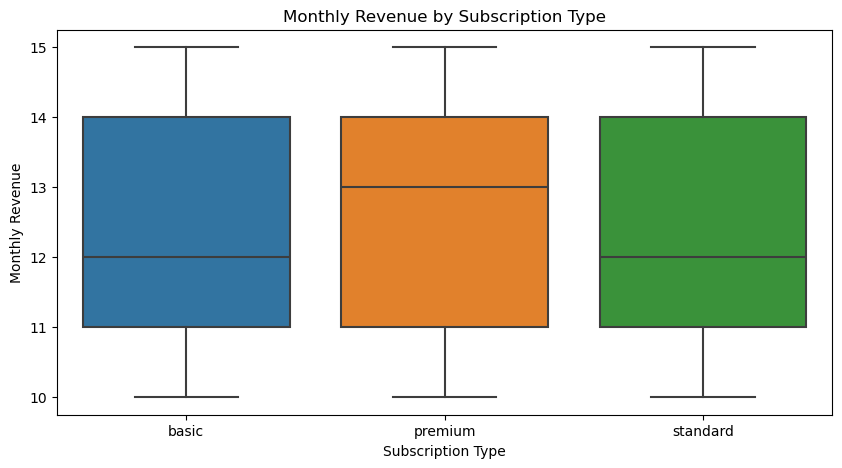

In [11]:
# Monthly Revenue vs Subscription Type
plt.figure(figsize=(10, 5))
sns.boxplot(x='Subscription Type', y='Monthly Revenue', data=userbase_df)
plt.title('Monthly Revenue by Subscription Type')
plt.show()

From the graph, we can see that all subscription types lie at the same points in the graph, with the same Interquartile Range from 11 to 14, with outliers at 10 and 15. Being the highest priced option among the subscription types, the Premium plan has the highest median Monthly Revenue.

We can begin to deduce from this initial analysis that the method used to generate this synthetic database skews toward creating a very even distribution.

### Age vs Monthly Revenue

This analysis aims to see the distribution of Monthly Revenue across the different age user age groups. A __scatterplot__ has been chosen to explore the relationship between the two continuous variables of Age and Monthly Revenue.

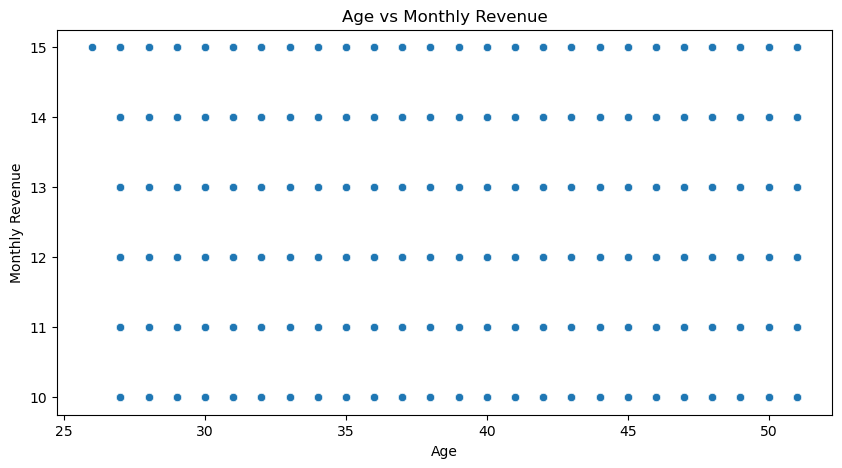

In [12]:
# Age vs Monthly Revenue
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Age', y='Monthly Revenue', data=userbase_df)
plt.title('Age vs Monthly Revenue')
plt.show()

Once again, a very even distribution across all age groups.

### Gender vs Monthly Revenue

A __boxplot__ is used once again for a continuous variable (Monthly Revenue) across different categories (Gender).

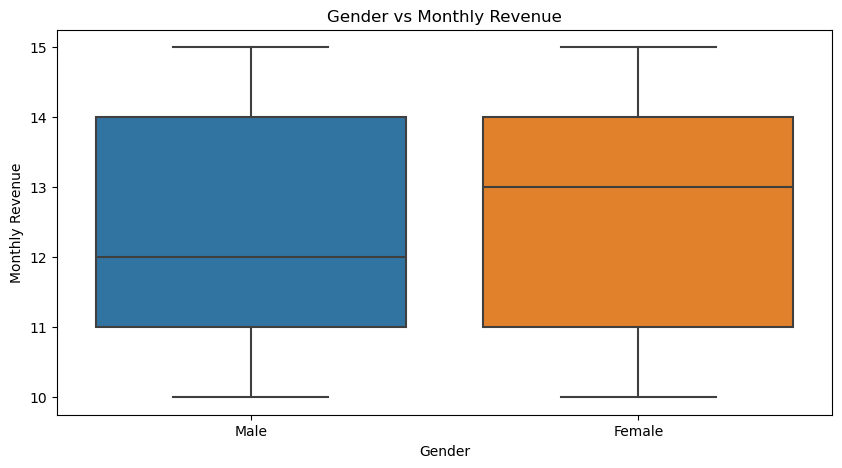

In [13]:
# Gender vs Monthly Revenue
plt.figure(figsize=(10, 5))
sns.boxplot(x='Gender', y='Monthly Revenue', data=userbase_df)
plt.title('Gender vs Monthly Revenue')
plt.show()

We see the same graph as the initial analysis, but this time comparing across the Gender variables. We see that Female users generate more Monthly Revenue overall with a __median__ of 14.

### Country vs Subscription Type

A __bar plot__ has been used to visualize the frequency distribution of categorical variables, in this case Country.

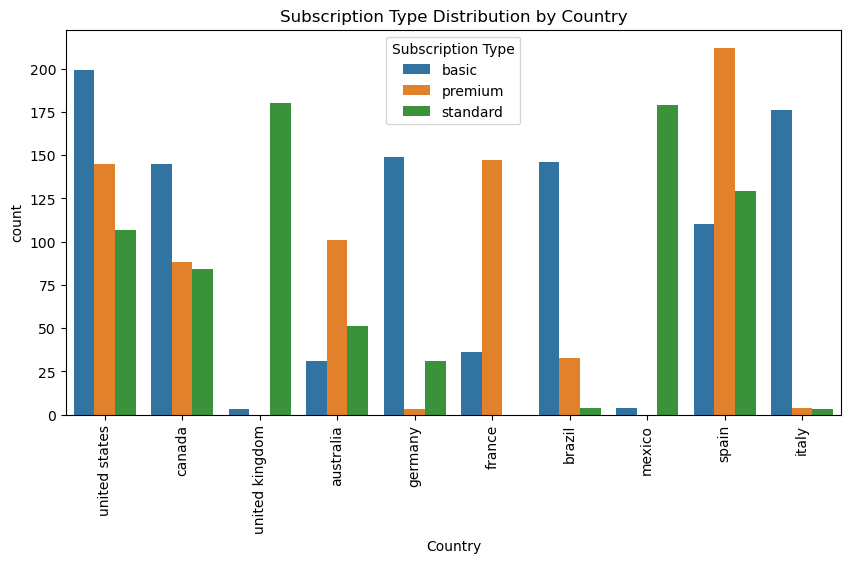

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Country', hue='Subscription Type', data=userbase_df)
plt.title('Subscription Type Distribution by Country')
plt.xticks(rotation=90)
plt.show()

Interestingly, this distribution is the least even of everything tested so far. Some countries tend towards a single subscription type, while some have a distributed count across all three.

### Device Type vs Subscription Type

__Bar plots__ are again chosen to show the distribution of subscription types across different device types.

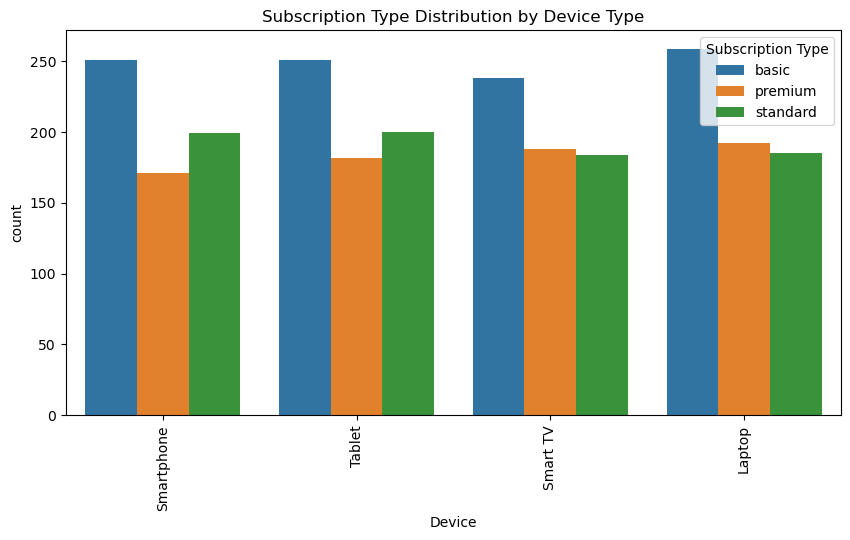

In [15]:
# Device Type vs Subscription Type
plt.figure(figsize=(10, 5))
sns.countplot(x='Device', hue='Subscription Type', data=userbase_df)
plt.title('Subscription Type Distribution by Device Type')
plt.xticks(rotation=90)
plt.show()

From our Bivariate Analysis, we can now proceed to formulating Exploratory Data Analysis questions, which will be detailed in the next section

## Question 1: What is the distribution of subscription types across different countries?

This section provides numerical summaries including measures of central tendency (mean, median) and dispersion (standard deviation), along with counts and percentages for each subscription type in the dataset.

This code calculates the count of each subscription type within each country and displays the results in a tabular format. It uses the [`groupby`](https://pandas.pydata.org/docs/reference/api/pandas.Series.groupby.html) function to group the data by 'Country' and 'Subscription Type', and then counts the occurrences with the size method. The [`reset_index`](https://pandas.pydata.org/docs/reference/api/pandas.Series.reset_index.html) function converts the grouped data back into a DataFrame, naming the new column 'Count'. Finally, it prints the subscription distribution across different countries.

In [16]:
# Group by 'Country' and 'Subscription Type', then count occurrences
subscription_distribution = userbase_df.groupby(['Country', 'Subscription Type']).size()

# Convert to DataFrame for better readability
subscription_distribution = subscription_distribution.reset_index(name='Count')

print("Distribution of Subscription Types across Different Countries:")
print(subscription_distribution)


Distribution of Subscription Types across Different Countries:
           Country Subscription Type  Count
0        australia             basic     31
1        australia           premium    101
2        australia          standard     51
3           brazil             basic    146
4           brazil           premium     33
5           brazil          standard      4
6           canada             basic    145
7           canada           premium     88
8           canada          standard     84
9           france             basic     36
10          france           premium    147
11         germany             basic    149
12         germany           premium      3
13         germany          standard     31
14           italy             basic    176
15           italy           premium      4
16           italy          standard      3
17          mexico             basic      4
18          mexico          standard    179
19           spain             basic    110
20           

This code visualizes the distribution of users across different subscription types in the dataset using a bar plot. It groups the data by 'Country' and 'Subscription Type' with the [`groupby`](https://pandas.pydata.org/docs/reference/api/pandas.Series.groupby.html) method, counts occurrences using [`size`](https://pandas.pydata.org/docs/reference/api/pandas.Series.size.html), and reshapes the data with [`unstack`](https://pandas.pydata.org/docs/reference/api/pandas.Series.unstack.html). The [`plot`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html) method creates a stacked bar chart, and figure configures the plot size. The plot is customized with [`title`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.title.html), xlabel, ylabel, xticks, and legend to enhance readability. Finally, the plot is displayed, showing the distribution of Basic, Standard, and Premium subscription plans across different countries.

<Figure size 1200x800 with 0 Axes>

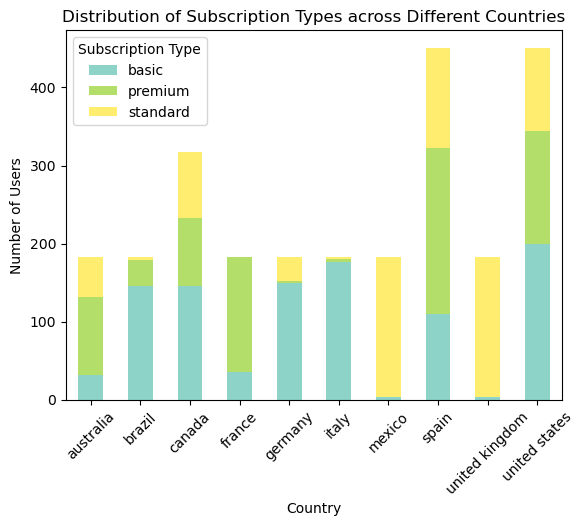

In [17]:
# Grouping data by 'Country' and 'Subscription Type' to get counts
subscription_counts = userbase_df.groupby(['Country', 'Subscription Type']).size().unstack()

# Plotting the grouped bar plot
plt.figure(figsize=(12, 8))
subscription_counts.plot(kind='bar', stacked=True, colormap='Set3')
plt.title('Distribution of Subscription Types across Different Countries')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Subscription Type')
plt.show()

## Question 2: How does the average monthly revenue vary for each subscription type across different countries?

This section provides numerical summaries, including measures of central tendency (mean, median) and dispersion (standard deviation) of monthly revenue for each subscription type across different countries. Additionally, it features appropriate visualizations to effectively showcase the findings.

This code calculates the mean, median, and standard deviation of monthly revenue for each subscription type within each country. It uses the [`groupby`](https://pandas.pydata.org/docs/reference/api/pandas.Series.groupby.html) function to group the data by 'Country' and 'Subscription Type', and then applies the [`agg`](https://pandas.pydata.org/docs/reference/api/pandas.Series.agg.html) function to compute the statistical measures (mean, median, std) for the 'Monthly Revenue' column. The results are stored in a new DataFrame named revenue_stats, which is reset using [`reset_index`](https://pandas.pydata.org/docs/reference/api/pandas.Series.reset_index.html) for better readability.

In [18]:
# Group by 'Country' and 'Subscription Type', then calculate mean, median, and standard deviation for Monthly Revenue
revenue_stats = userbase_df.groupby(['Country', 'Subscription Type'])['Monthly Revenue'].agg(['mean', 'median', 'std']).reset_index()

print("Measures of Central Tendency and Dispersion for Monthly Revenue by Subscription Type across Different Countries:")
print(revenue_stats)


Measures of Central Tendency and Dispersion for Monthly Revenue by Subscription Type across Different Countries:
           Country Subscription Type       mean  median       std
0        australia             basic  12.193548    12.0  1.759154
1        australia           premium  12.415842    12.0  1.716201
2        australia          standard  12.529412    12.0  1.591891
3           brazil             basic  12.493151    13.0  1.727053
4           brazil           premium  12.424242    12.0  1.677616
5           brazil          standard  12.750000    13.0  1.500000
6           canada             basic  12.524138    12.0  1.671172
7           canada           premium  12.340909    12.0  1.639220
8           canada          standard  12.476190    12.0  1.631587
9           france             basic  12.361111    12.0  1.457057
10          france           premium  12.666667    13.0  1.713497
11         germany             basic  12.302013    12.0  1.630390
12         germany           

This code features a stacked bar plot visualizing the average monthly revenue for each subscription type across different countries. It utilizes the  `revenue_stats` DataFrame, which aggregates data by 'Country' and 'Subscription Type' to calculate mean values for 'Monthly Revenue'. The [`plot`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html) function is used with `kind='bar'` and `stacked=True` parameters to create a stacked bar chart. The data is then reshaped using [`pivot`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pivot.html) to set 'Country' as the index, 'Subscription Type' as columns, and 'mean' as the values. This visualization effectively compares revenue patterns among different subscription types across multiple countries.

<Figure size 1200x800 with 0 Axes>

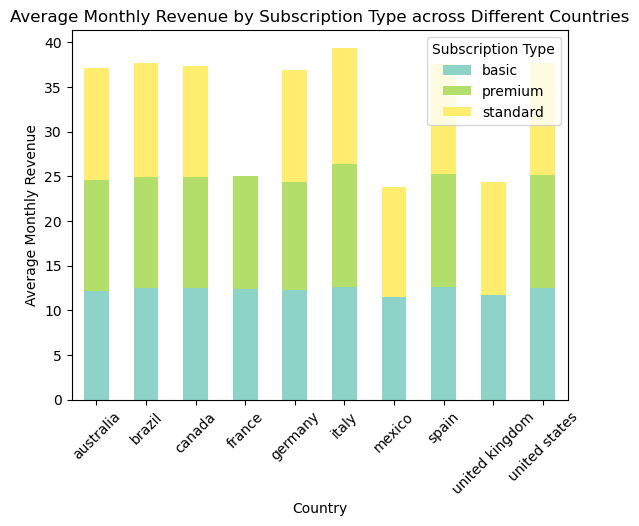

In [19]:
# Plotting the grouped bar plot for average monthly revenue by subscription type across different countries
plt.figure(figsize=(12, 8))
revenue_stats.pivot(index='Country', columns='Subscription Type', values='mean').plot(kind='bar', stacked=True, colormap='Set3')

plt.title('Average Monthly Revenue by Subscription Type across Different Countries')
plt.xlabel('Country')
plt.ylabel('Average Monthly Revenue')
plt.xticks(rotation=45)
plt.legend(title='Subscription Type')
plt.show()

## Question 3: Are there significant differences in subscription type preferences between countries with diverse demographics (e.g., age, gender, country)?

To analyze subscription type preferences across different demographic variables like age, gender, and country, we'll first conduct numerical summaries using cross-tabulations and statistical tests (specifically the chi-square test for independence). Then, we'll visualize these relationships using heatmaps and stacked bar plots.

This code creates a contingency table (cross-tabulation) for Subscription Type by Country using `pd.crosstab`. The table shows the count of each subscription type within each country.

In [20]:
# Creating a cross-tabulation of Subscription Type and Country
subscription_country_xtab = pd.crosstab(userbase_df['Country'], userbase_df['Subscription Type'])

# Displaying the cross-tabulation
print("Cross-tabulation of Subscription Type by Country:")
print(subscription_country_xtab)
print()

Cross-tabulation of Subscription Type by Country:
Subscription Type  basic  premium  standard
Country                                    
australia             31      101        51
brazil               146       33         4
canada               145       88        84
france                36      147         0
germany              149        3        31
italy                176        4         3
mexico                 4        0       179
spain                110      212       129
united kingdom         3        0       180
united states        199      145       107



This code performs a chi-square test of independence on the cross-tabulation to assess whether there is a significant association between Subscription Type and Country using the [`chi2_contingency`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html) function from scipy.stats

In [21]:
# Performing chi-square test of independence for Subscription Type and Country
chi2, p, dof, expected = chi2_contingency(subscription_country_xtab)
print(f"Chi-square test statistic: {chi2}")
print(f"P-value: {p}")
print()

Chi-square test statistic: 1683.851480824555
P-value: 0.0



This code creates a contingency table for Subscription Type by Age Group.

In [22]:
# Creating cross-tabulations for Subscription Type by Age Group 
subscription_age_xtab = pd.crosstab(userbase_df['Age'], userbase_df['Subscription Type'])

# Displaying the cross-tabulations
print("Cross-tabulation of Subscription Type by Age Group:")
print(subscription_age_xtab)
print()

Cross-tabulation of Subscription Type by Age Group:
Subscription Type  basic  premium  standard
Age                                        
26                     0        1         0
27                    34       32        21
28                    40       41        34
29                    49       24        31
30                    48       37        31
31                    53       36        26
32                    40       25        27
33                    28       33        32
34                    28       24        36
35                    34       32        39
36                    45       36        18
37                    41       28        38
38                    40       18        31
39                    62       24        30
40                    35       33        35
41                    34       41        39
42                    37       22        43
43                    41       24        29
44                    33       28        25
45                    37

This code performs a chi-square test of independence on the cross-tabulation to assess whether there is a significant association between Subscription Type and Age Group.

In [23]:
# Performing chi-square test of independence for Subscription Type and Age Group
chi2_age, p_age, dof_age, expected_age = chi2_contingency(subscription_age_xtab)
print(f"Chi-square test statistic for Age Group: {chi2_age}")
print(f"P-value for Age Group: {p_age}")
print()

Chi-square test statistic for Age Group: 73.12866547412389
P-value for Age Group: 0.018131908747004436



This code creates a contingency table for Subscription Type by Gender.

In [24]:
# Creating cross-tabulations for Subscription Type by Gender
subscription_gender_xtab = pd.crosstab(userbase_df['Gender'], userbase_df['Subscription Type'])

# Displaying the cross-tabulations
print("Cross-tabulation of Subscription Type by Gender:")
print(subscription_gender_xtab)
print()

Cross-tabulation of Subscription Type by Gender:
Subscription Type  basic  premium  standard
Gender                                     
Female               512      364       381
Male                 487      369       387



This code performs a chi-square test of independence on the cross-tabulation to assess whether there is a significant association between Subscription Type and Gender.

In [25]:
# Performing chi-square test of independence for Subscription Type and Gender
chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(subscription_gender_xtab)
print(f"Chi-square test statistic for Gender: {chi2_gender}")
print(f"P-value for Gender: {p_gender}")

Chi-square test statistic for Gender: 0.6282267388216123
P-value for Gender: 0.7304362143419852


This heatmap visualizes the distribution of Subscription Type preferences across different countries. The heatmap uses the subscription_country_xtab table, where each cell's color intensity represents the count of users subscribing to a particular type within a specific country.

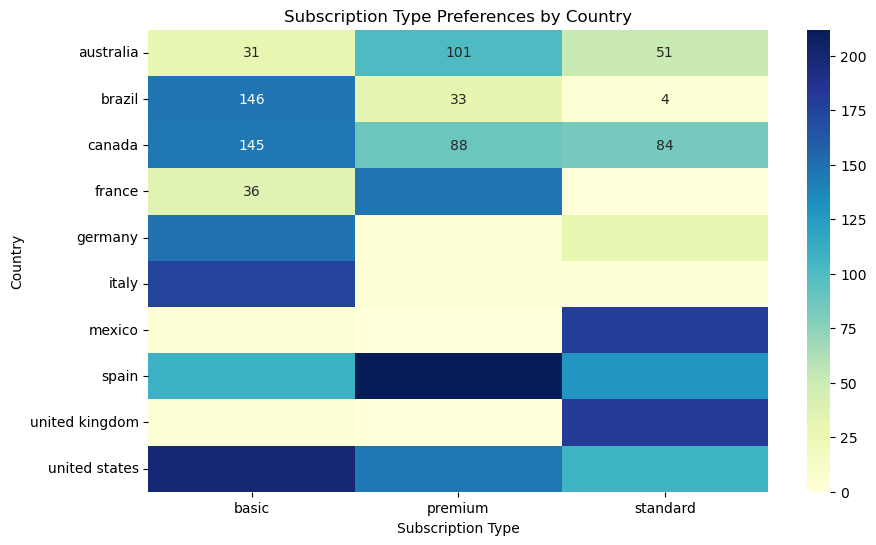

In [26]:
# Heatmap of Subscription Type by Country
plt.figure(figsize=(10, 6))
sns.heatmap(subscription_country_xtab, annot=True, cmap="YlGnBu", fmt="d")
plt.title('Subscription Type Preferences by Country')
plt.xlabel('Subscription Type')
plt.ylabel('Country')
plt.show()

This stacked bar plot illustrates how Subscription Type preferences vary across Age Groups. Each bar represents the total count of subscriptions within each age group, stacked by Subscription Type.

<Figure size 1000x600 with 0 Axes>

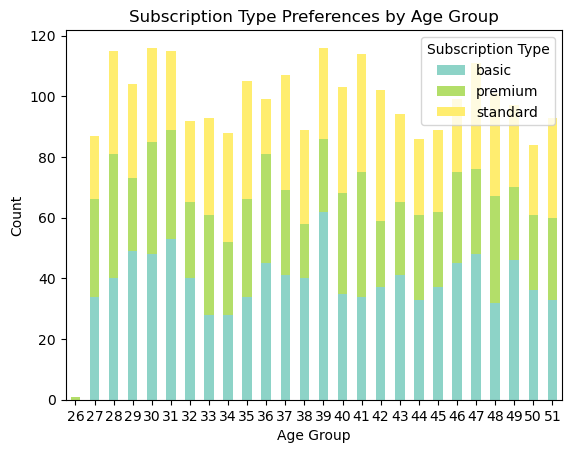

In [27]:
# Stacked bar plot of Subscription Type by Age Group
plt.figure(figsize=(10, 6))
subscription_age_xtab.plot(kind='bar', stacked=True, cmap='Set3')
plt.title('Subscription Type Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Subscription Type')
plt.show()

This stacked bar plot illustrates how Subscription Type preferences vary across Genders. Each bar represents the total count of subscriptions within each gender category, stacked by Subscription Type.

<Figure size 800x600 with 0 Axes>

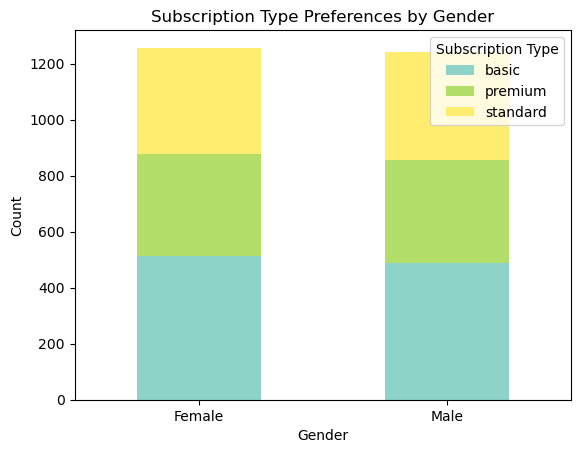

In [28]:
# Stacked bar plot of Subscription Type by Gender
plt.figure(figsize=(8, 6))
subscription_gender_xtab.plot(kind='bar', stacked=True, cmap='Set3')
plt.title('Subscription Type Preferences by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Subscription Type')
plt.show()

## Question 4: Can we identify any clusters of countries based on similar patterns of subscription type preferences?

For this question, we'll need to conduct the following steps: 
- Aggregating the data to get the distribution type for each country
- Normalize the aggregated data
- Cluster using K-means
- Visualize the clusters

For readability and modularity, the functions for these tasks have been placed into the __clustering_analysis.py__ file and imported in the initial notebook setup.

We will now proceed to the data preparation:

In [29]:
# Prepare the data
country_subscription_counts, country_subscription_scaled_df = ca.prepare_data(userbase_df)

country_subscription_counts

Subscription Type,basic,premium,standard
Country,,,
australia,31,101,51
brazil,146,33,4
canada,145,88,84
france,36,147,0
germany,149,3,31
italy,176,4,3
mexico,4,0,179
spain,110,212,129
united kingdom,3,0,180



The next step is to use K-means clustering to determine the optimal number of clusters. We will be storing it as __wcss__, or __Within-Cluster Sum of Squares__, which in the context of K-means, is the measure of total variance. We then use it to evaluate the compactness of the clusters.


In [30]:
# Determine the optimal number of clusters
wcss = ca.determine_optimal_clusters(country_subscription_scaled_df, n_init=10)

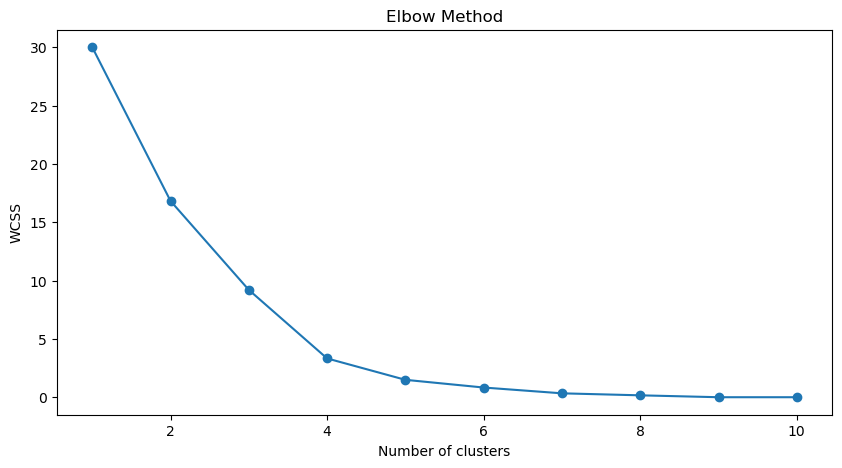

In [31]:
ca.plot_elbow_method(wcss)

In the Elbow Method, we look for the point in the graph where the line moves almost parallel to the X-axis, forming the 'elbow'. In our given graph, we can see that this happens at around the 5 cluster mark. As such, this is the number we will be using.

In [32]:
# Perform clustering
optimal_clusters = 5
clusters = ca.perform_clustering(country_subscription_scaled_df, optimal_clusters, n_init=10)

After clustering, we can now perform some preliminary steps before visualizing our clusters. 

In [33]:
# Add cluster labels to the DataFrame
ca.add_cluster_labels(country_subscription_counts, clusters)

Finally, we can plot our data to a barplot as well as visualize the clusters we created.

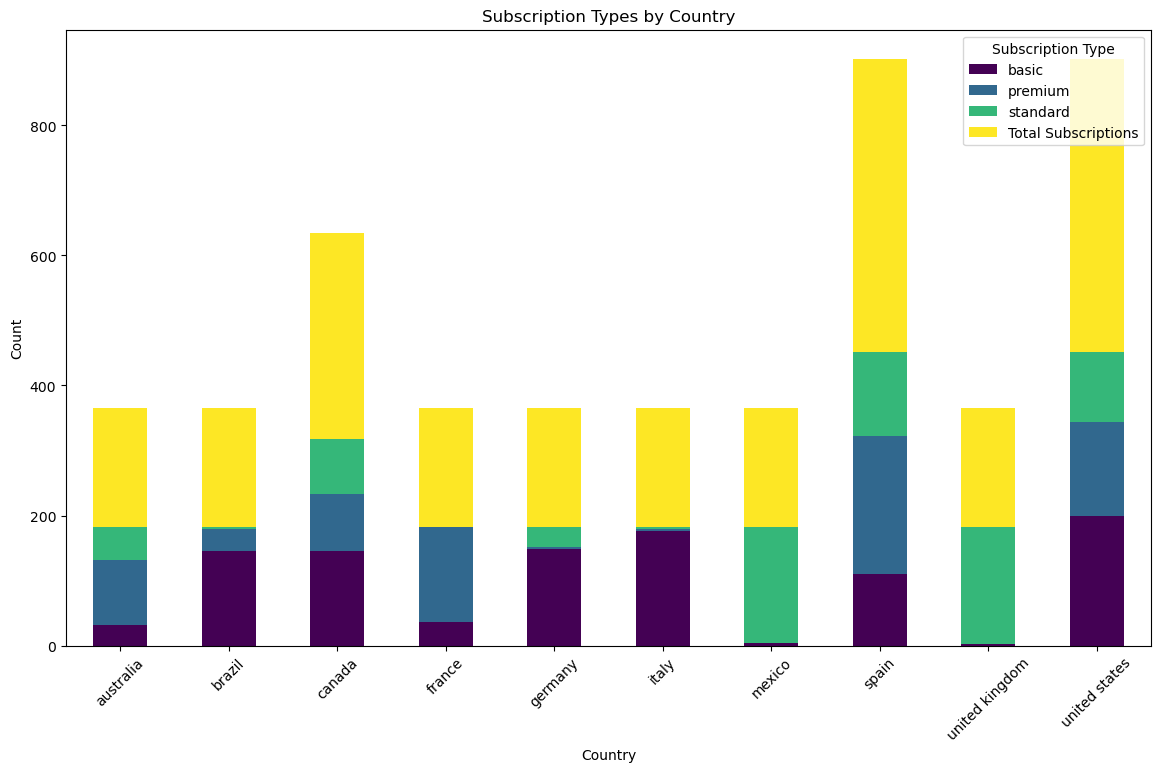

In [34]:
# Plot the barplot of subscription types by country
ca.plot_barplot(country_subscription_counts)

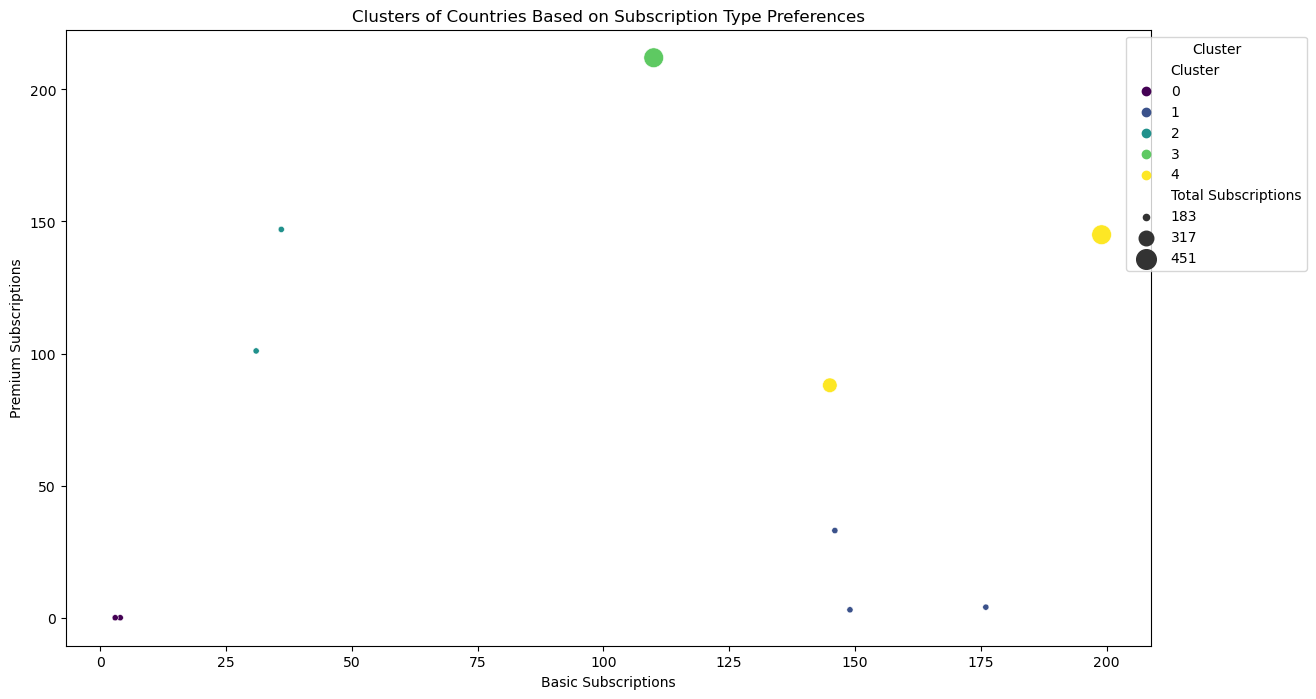

In [35]:
# Visualize the cluster assignment
ca.plot_clusters(country_subscription_counts)

In [36]:
ca.display_cluster_info(country_subscription_counts)

Cluster Information:

Cluster 0:
Number of countries: 2
Countries:  mexico, united kingdom
Average subscription counts:
Subscription Type
basic                    3.5
premium                  0.0
standard               179.5
Total Subscriptions    183.0
Name: 0, dtype: float64
--------------------------

Cluster 1:
Number of countries: 3
Countries:  brazil, germany, italy
Average subscription counts:
Subscription Type
basic                  157.000000
premium                 13.333333
standard                12.666667
Total Subscriptions    183.000000
Name: 1, dtype: float64
--------------------------

Cluster 2:
Number of countries: 2
Countries:  australia, france
Average subscription counts:
Subscription Type
basic                   33.5
premium                124.0
standard                25.5
Total Subscriptions    183.0
Name: 2, dtype: float64
--------------------------

Cluster 3:
Number of countries: 1
Countries:  spain
Average subscription counts:
Subscription Type
basic       

# IV. Research Question

In this section of the notebook, the research question drives the focus of our data analysis project and and is derived from insights obtained during the exploratory data analysis (EDA).

The exploratory data analysis highlighted patterns in Netflix subscription preferences across different countries. By examining the distribution of subscription types and analyzing revenue statistics, we identified significant patterns in user behavior related to subscription choices. This led to the formulation of the research question:

<div style="text-align: center;"><strong><em>Are there any patterns in subscription type preferences based on country?</em></strong></div>

Answering this research question may help Netflix in (1) adjusting its content offerings and subscription plans to better align with regional preferences, and (2) developing targeted marketing strategies based on country-specific subscription patterns. These insights can lead to enhanced user satisfaction, increased retention rates, and optimized business operations, ultimately supporting Netflix's global market expansion and consumer engagement efforts.

# PHASE 2

This phase of the project will focus on answering the research question formulated in Phase 1. To answer this, we will be conducting __Data Modeling and Statistical Inference.__

## I. Data Modeling

Since the research question aims to find a __pattern__ in the subscription type preferences, we will be using __Association Rule Mining__, in particular Market Basket Analysis. MBA will be used to identify relationships between variables that occur simultaneously given a certain Subscription Type. 

### Setup

To perform Data Modeling, we will need to install and import the __MLxtend__ library, which contains tools and extensions for data analysis and machine learning.

In [37]:
!pip install mlxtend


Next up is importing the library into our notebook.

In [38]:
import mlxtend
from mlxtend.frequent_patterns import association_rules, apriori


### Preprocessing

To perform MBA, we will be needing the __Apriori__ algorithm from the __MLxtend__ library. Apriori requires the data to be in a specific format, typically in the form of a transaction dataset where each transaction contains a list of items. In our case, we will be converting the dataframe to one-hot encoding, where the subscription type of the user will be highlighted with a value of __1__.

We will first convert the data into a pivot table, then change the values for one-hot encoding.

In [39]:
userbase_df_pivot = userbase_df.pivot_table(index='Country', columns='Subscription Type', values='User ID', aggfunc='count')
print("Dataset size: ", userbase_df_pivot.shape)
userbase_df_pivot

Dataset size:  (10, 3)


Subscription Type,basic,premium,standard
Country,,,
australia,31.0,101.0,51.0
brazil,146.0,33.0,4.0
canada,145.0,88.0,84.0
france,36.0,147.0,NaN
germany,149.0,3.0,31.0
italy,176.0,4.0,3.0
mexico,4.0,NaN,179.0
spain,110.0,212.0,129.0
united kingdom,3.0,NaN,180.0


Next up is converting to one-hot. The values in our table aren't simply 'exists' and 'does not exist', i.e. they take on a range of values, thus not offering a direct conversion to one-hot. In this case, we will be testing across a few different thresholds to better evaluate how they impact the results. This will help us determine the optimal threshold for our analysis.

In [40]:
# Threshold set to 100 users
userbase_df_pivot_binary100 = userbase_df_pivot.map(lambda x: ca.apply_threshold(x, 100))

# Threshold set to 75 users
userbase_df_pivot_binary75 = userbase_df_pivot.map(lambda x: ca.apply_threshold(x, 75))

# Threshold set to 50 users
userbase_df_pivot_binary50 = userbase_df_pivot.map(lambda x: ca.apply_threshold(x, 50))


userbase_df_pivot_binary100

Subscription Type,basic,premium,standard
Country,,,
australia,0,1,0
brazil,1,0,0
canada,1,0,0
france,0,1,0
germany,1,0,0
italy,1,0,0
mexico,0,0,1
spain,1,1,1
united kingdom,0,0,1


In [41]:
userbase_df_pivot_binary75

Subscription Type,basic,premium,standard
Country,,,
australia,0,1,0
brazil,1,0,0
canada,1,1,1
france,0,1,0
germany,1,0,0
italy,1,0,0
mexico,0,0,1
spain,1,1,1
united kingdom,0,0,1


In [42]:
userbase_df_pivot_binary50

Subscription Type,basic,premium,standard
Country,,,
australia,0,1,1
brazil,1,0,0
canada,1,1,1
france,0,1,0
germany,1,0,0
italy,1,0,0
mexico,0,0,1
spain,1,1,1
united kingdom,0,0,1


### Apriori Algorithm for  Threshold = 100


In [43]:
#Minimum threshold
support = 0.2 
frequent_items100 = apriori(userbase_df_pivot_binary100, min_support=support, use_colnames=True)
frequent_items100.sort_values('support', ascending=False)

D:\anaconda\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.6,(basic)
1,0.4,(premium)
2,0.4,(standard)
3,0.2,"(premium, basic)"
4,0.2,"(standard, basic)"
5,0.2,"(premium, standard)"
6,0.2,"(premium, standard, basic)"


### Association Rules for Threshold = 100

In [44]:
metric = 'lift'
min_treshold = 1

rules100 = association_rules(frequent_items100, metric=metric, min_threshold=min_treshold)[['antecedents','consequents','support','confidence','lift']]
rules100.reset_index(drop=True).sort_values('confidence',ascending=False, inplace = True)
rules100

,antecedents,consequents,support,confidence,lift
0,(premium),(standard),0.2,0.500000,1.250000
1,(standard),(premium),0.2,0.500000,1.250000
2,"(premium, standard)",(basic),0.2,1.000000,1.666667
3,"(premium, basic)",(standard),0.2,1.000000,2.500000
4,"(standard, basic)",(premium),0.2,1.000000,2.500000
5,(premium),"(standard, basic)",0.2,0.500000,2.500000
6,(standard),"(premium, basic)",0.2,0.500000,2.500000
7,(basic),"(premium, standard)",0.2,0.333333,1.666667


### Interpretations

#### Rule 1 (index 0) and 2 (index 1):

- Antecedents: (standard)
- Consequents: (premium)
- Support: 0.2
- Confidence: 0.5
- Lift: 1.25
Interpretation: This rule indicates that 20% of the transactions include the 'standard' subscription type, and among those transactions, 50% also include the 'premium' subscription type. The lift of 1.25 suggests a slight positive association between 'standard' and 'premium'; transactions containing 'standard' are 1.25 times more likely to contain 'premium' compared to their individual probabilities.

#### Rule 3 (index 2):

- Antecedents: (basic, standard)
- Consequents: (premium)
- Support: 0.2
- Confidence: 1.0
- Lift: 2.5
- Interpretation: In 20% of the transactions, both 'basic' and 'standard' subscription types are present. Among these transactions, there is a 100% confidence that 'premium' will also be present. The lift of 2.5 indicates a strong positive association between 'basic' and 'standard' with 'premium'; transactions containing both 'basic' and 'standard' are 2.5 times more likely to contain 'premium' compared to their individual probabilities.

#### Rule 4 (index 3):

- Antecedents: (basic, premium)
- Consequents: (standard)
- Support: 0.2
- Confidence: 1.0
- Lift: 2.5
- Interpretation: Similar to Rule 3, in 20% of the transactions where both 'basic' and 'premium' subscription types are present, there is 100% confidence that 'standard' will also be present. The lift of 2.5 indicates a strong positive association between 'basic' and 'premium' with 'standard'; transactions containing both 'basic' and 'premium' are 2.5 times more likely to contain 'standard' compared to their individual probabilities

#### Rule 5 (index 4):

- Antecedents: (standard, premium)
- Consequents: (basic)
- Support: 0.2
- Confidence: 1.0
- Lift: 1.67
- Interpretation: This rule shows that in 20% of the transactions where both 'standard' and 'premium' are present, there is 100% confidence that 'basic' will also be present. The lift of 1.67 indicates a moderate positive association between 'standard' and 'premium' with 'basic'; transactions containing both 'standard' and 'premium' are 1.67 times more likely to contain 'basic' compared to their individual probabilities.

### Insights:

- __Strong Associations__: Rules 3 and 4 highlight strong associations where the presence of 'basic' and 'standard' or 'basic' and 'premium' together significantly increases the likelihood of the other subscription type being present.


- __Moderate Associations__: Rule 1 and 2 indicate moderate associations between 'standard' and 'premium', suggesting that customers who subscribe to 'standard' may also show interest in 'premium', and vice versa.

### Apriori Algotrithm for Threshold = 75

In [45]:
#Minimum threshold
support = 0.2 
frequent_items75 = apriori(userbase_df_pivot_binary75, min_support=support, use_colnames=True)
frequent_items75.sort_values('support', ascending=False)

D:\anaconda\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.6,(basic)
1,0.5,(premium)
2,0.5,(standard)
3,0.3,"(premium, basic)"
4,0.3,"(standard, basic)"
5,0.3,"(premium, standard)"
6,0.3,"(premium, standard, basic)"


### Association Rules for Threshold = 75

In [46]:
metric = 'lift'
min_treshold = 1

rules75 = association_rules(frequent_items75, metric=metric, min_threshold=min_treshold)[['antecedents','consequents','support','confidence','lift']]
rules75.reset_index(drop=True).sort_values('confidence',ascending=False, inplace = True)
rules75

,antecedents,consequents,support,confidence,lift
0,(premium),(basic),0.3,0.6,1.000000
1,(basic),(premium),0.3,0.5,1.000000
2,(standard),(basic),0.3,0.6,1.000000
3,(basic),(standard),0.3,0.5,1.000000
4,(premium),(standard),0.3,0.6,1.200000
5,(standard),(premium),0.3,0.6,1.200000
6,"(premium, standard)",(basic),0.3,1.0,1.666667
7,"(premium, basic)",(standard),0.3,1.0,2.000000
8,"(standard, basic)",(premium),0.3,1.0,2.000000
9,(premium),"(standard, basic)",0.3,0.6,2.000000


### Interpretations


#### Rule 1 (index 0):
- Antecedents: (premium)
- Consequents: (basic)
- Support: 0.3
- Confidence: 0.6
- Lift: 1.0
- Interpretation: In 30% of the transactions where 'premium' subscription type is present, there is 60% confidence that 'basic' subscription type will also be present. The lift of 1.0 indicates that there is no significant association beyond what would be expected by chance.


#### Rule 2 (index 1):
- Antecedents: (basic)
- Consequents: (premium)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.0
- Interpretation: Similar to Rule 0, in 30% of the transactions where 'basic' subscription type is present, there is 50% confidence that 'premium' subscription type will also be present. The lift of 1.0 indicates no significant association beyond chance.


#### Rule 3 (index 2):
- Antecedents: (standard)
- Consequents: (basic)
- Support: 0.3
- Confidence: 0.6
- Lift: 1.0
- Interpretation: Similar to Rule 0, in 30% of the transactions where 'standard' subscription type is present, there is 60% confidence that 'basic' subscription type will also be present. The lift of 1.0 indicates no significant association beyond chance.


#### Rule 4 (index 3):
- Antecedents: (basic)
- Consequents: (standard)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.0
- Interpretation: Similar to Rule 2, in 30% of the transactions where 'basic' subscription type is present, there is 50% confidence that 'standard' subscription type will also be present. The lift of 1.0 indicates no significant association beyond chance.


#### Rule 5 (index 4):
- Antecedents: (standard)
- Consequents: (premium)
- Support: 0.3
- Confidence: 0.6
- Lift: 1.2
- Interpretation: In 30% of the transactions where 'standard' subscription type is present, there is 60% confidence that 'premium' subscription type will also be present. The lift of 1.2 indicates a slightly higher likelihood of 'premium' being associated with 'standard' compared to their individual probabilities.


#### Rule 6 (index 5):
- Antecedents: (premium)
- Consequents: (standard)
- Support: 0.3
- Confidence: 0.6
- Lift: 1.2
- Interpretation: Similar to Rule 4, in 30% of the transactions where 'premium' subscription type is present, there is 60% confidence that 'standard' subscription type will also be present. The lift of 1.2 indicates a slightly higher likelihood of 'standard' being associated with 'premium' compared to their individual probabilities.


#### Rule 7 (index 6):
- Antecedents: (standard, premium)
- Consequents: (basic)
- Support: 0.3
- Confidence: 1.0
- Lift: 1.67
- Interpretation: In 30% of the transactions where both 'standard' and 'premium' subscription types are present, there is 100% confidence that 'basic' subscription type will also be present. The lift of 1.67 indicates a moderate positive association between 'standard' and 'premium' with 'basic'; transactions containing both 'standard' and 'premium' are 1.67 times more likely to contain 'basic' compared to their individual probabilities.


#### Rule 8 (index 7):
- Antecedents: (standard, basic)
- Consequents: (premium)
- Support: 0.3
- Confidence: 1.0
- Lift: 2.0
- Interpretation: In 30% of the transactions where both 'standard' and 'basic' subscription types are present, there is 100% confidence that 'premium' subscription type will also be present. The lift of 2.0 indicates a strong positive association between 'standard' and 'basic' with 'premium'; transactions containing both 'standard' and 'basic' are 2.0 times more likely to contain 'premium' compared to their individual probabilities.


#### Rule 9 (index 8):
- Antecedents: (premium, basic)
- Consequents: (standard)
- Support: 0.3
- Confidence: 1.0
- Lift: 2.0
- Interpretation: In 30% of the transactions where both 'premium' and 'basic' subscription types are present, there is 100% confidence that 'standard' subscription type will also be present. The lift of 2.0 indicates a strong positive association between 'premium' and 'basic' with 'standard'; transactions containing both 'premium' and 'basic' are 2.0 times more likely to contain 'standard' compared to their individual probabilities.


#### Rule 10 (index 9):
- Antecedents: (standard)
- Consequents: (premium, basic)
- Support: 0.3
- Confidence: 0.6
- Lift: 2.0
- Interpretation: In 30% of the transactions where 'standard' subscription type is present, there is 60% confidence that both 'premium' and 'basic' subscription types will also be present. The lift of 2.0 indicates a moderate positive association between 'standard' with 'premium' and 'basic'; transactions containing 'standard' are 2.0 times more likely to contain both 'premium' and 'basic' compared to their individual probabilities.


#### Rule 11 (index 10):
- Antecedents: (premium)
- Consequents: (standard, basic)
- Support: 0.3
- Confidence: 0.6
- Lift: 2.0
- Interpretation: Similar to Rule 9, in 30% of the transactions where 'premium' subscription type is present, there is 60% confidence that both 'standard' and 'basic' subscription types will also be present. The lift of 2.0 indicates a moderate positive association between 'premium' with 'standard' and 'basic'; transactions containing 'premium' are 2.0 times more likely to contain both 'standard' and 'basic' compared to their individual probabilities.


#### Rule 12 (index 11):
- Antecedents: (basic)
- Consequents: (standard, premium)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.67
- Interpretation: In 30% of the transactions where 'basic' subscription type is present, there is 50% confidence that both 'standard' and 'premium' subscription types will also be present. The lift of 1.67 indicates a moderate positive association between 'basic' with 'standard' and 'premium'; transactions containing 'basic' are 1.67 times more likely to contain both 'standard' and 'premium' compared to their individual probabilities.

### Insights:

- __Strong Associations__: Rules 6, 7, and 8 indicate strong associations where the presence of combinations like 'standard' and 'premium' with 'basic' significantly increases the likelihood of the other subscription type(s) being present. For example, transactions with both 'standard' and 'premium' are 2.0 times more likely to also include 'basic'.

- __Moderate Associations__: Rules 0, 1, 2, 3, 4, 5, 9, 10, and 11 suggest moderate associations between various subscription types. These rules indicate that certain subscription types tend to co-occur together with confidence levels ranging from 50% to 60%. For instance, customers subscribing to 'premium' are 60% likely to also have 'basic', and vice versa

### Apriori Algotrithm for Threshold = 50

In [47]:
#Minimum threshold
support = 0.2 
frequent_items50 = apriori(userbase_df_pivot_binary50, min_support=support, use_colnames=True)
frequent_items50.sort_values('support', ascending=False)

D:\anaconda\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.6,(basic)
2,0.6,(standard)
1,0.5,(premium)
5,0.4,"(premium, standard)"
3,0.3,"(premium, basic)"
4,0.3,"(standard, basic)"
6,0.3,"(premium, standard, basic)"


### Association Rules for Threshold = 50

In [48]:
metric = 'lift'
min_treshold = 1

rules50 = association_rules(frequent_items50, metric=metric, min_threshold=min_treshold)[['antecedents','consequents','support','confidence','lift']]
rules50.reset_index(drop=True).sort_values('confidence',ascending=False, inplace = True)
rules50

,antecedents,consequents,support,confidence,lift
0,(premium),(basic),0.3,0.600000,1.000000
1,(basic),(premium),0.3,0.500000,1.000000
2,(premium),(standard),0.4,0.800000,1.333333
3,(standard),(premium),0.4,0.666667,1.333333
4,"(premium, standard)",(basic),0.3,0.750000,1.250000
5,"(premium, basic)",(standard),0.3,1.000000,1.666667
6,"(standard, basic)",(premium),0.3,1.000000,2.000000
7,(premium),"(standard, basic)",0.3,0.600000,2.000000
8,(standard),"(premium, basic)",0.3,0.500000,1.666667
9,(basic),"(premium, standard)",0.3,0.500000,1.250000


### Interpretations

#### Rule 1 (index 0):
- Antecedents: (basic)
- Consequents: (premium)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.0
- Interpretation: In 30% of the transactions where 'basic' is present, there is 50% confidence that 'premium' will also be present. The lift of 1.0 indicates that there is no significant association beyond what would be expected by chance.


#### Rule 2 (index 1):
- Antecedents: (premium)
- Consequents: (basic)
- Support: 0.3
- Confidence: 0.6
- Lift: 1.0
- Interpretation: Similar to Rule 1, in 30% of the transactions where 'premium' is present, there is 60% confidence that 'basic' will also be present. The lift of 1.0 indicates no significant association beyond chance.


#### Rule 3 (index 2):
- Antecedents: (standard)
- Consequents: (premium)
- Support: 0.4
- Confidence: 0.67
- Lift: 1.33
- Interpretation: In 40% of the transactions where 'standard' is present, there is 67% confidence that 'premium' will also be present. The lift of 1.33 suggests a moderate positive association between 'standard' and 'premium'.


#### Rule 4 (index 3):
- Antecedents: (premium)
- Consequents: (standard)
- Support: 0.4
- Confidence: 0.8
- Lift: 1.33
- Interpretation: Conversely to Rule 3, in 40% of the transactions where 'premium' is present, there is 80% confidence that 'standard' will also be present. This reciprocal lift of 1.33 further supports the association between 'premium' and 'standard'.


#### Rule 5 (index 4):
- Antecedents: (basic, standard)
- Consequents: (premium)
- Support: 0.3
- Confidence: 1.0
- Lift: 2.0
- Interpretation: Transactions containing both 'basic' and 'standard' are 2.0 times more likely to include 'premium' as well, with 100% confidence. The lift of 2.0 indicates a strong positive association between 'basic', 'standard', and 'premium'.


#### Rule 6 (index 5):
- Antecedents: (standard, premium)
- Consequents: (basic)
- Support: 0.3
- Confidence: 0.75
- Lift: 1.25
- Interpretation: In 30% of the transactions where both 'standard' and 'premium' are present, there is 75% confidence that 'basic' will also be present. The lift of 1.25 suggests a moderate association between 'standard', 'premium', and 'basic'.


#### Rule 7 (index 6):
- Antecedents: (basic, premium)
- Consequents: (standard)
- Support: 0.3
- Confidence: 1.0
- Lift: 1.67
- Interpretation: Transactions with both 'basic' and 'premium' are 1.67 times more likely to include 'standard' as well, with 100% confidence. This indicates a strong positive association between 'basic', 'premium', and 'standard'.


#### Rule 8 (index 7):
- Antecedents: (standard)
- Consequents: (basic, premium)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.67
- Interpretation: Conversely to Rule 7, in 30% of the transactions where 'standard' is present, there is 50% confidence that both 'basic' and 'premium' will also be present. The lift of 1.67 suggests a moderate association between 'standard', 'basic', and 'premium'.


#### Rule 9 (index 8):
- Antecedents: (basic)
- Consequents: (standard, premium)
- Support: 0.3
- Confidence: 0.5
- Lift: 1.25
- Interpretation: In 30% of the transactions where 'basic' is present, there is 50% confidence that both 'standard' and 'premium' will also be present. The lift of 1.25 indicates a moderate association between 'basic', 'standard', and 'premium'.


#### Rule 10 (index 9):
- Antecedents: (premium)
- Consequents: (basic, standard)
- Support: 0.3
- Confidence: 0.6
- Lift: 2.0
- Interpretation: Transactions containing 'premium' are 2.0 times more likely to include both 'basic' and 'standard' as well, with 60% confidence. This strong lift of 2.0 suggests a significant association between 'premium', 'basic', and 'standard'.

### Insights:

- __Strong Associations__: Rules 5, 7, and 10 highlight strong associations where the presence of combinations like 'basic' and 'standard' or 'basic', 'premium', and 'standard' significantly increases the likelihood of the other subscription type being present. These rules have high confidence values (1.0) and lifts indicating strong positive associations.

- __Moderate Associations__: Rules 3, 4, 6, 8, and 9 indicate moderate associations between various subscription types. For example:
    - Rule 3 and 4 show moderate associations between 'standard' and 'premium', suggesting that customers who subscribe to 'standard' may also show interest in 'premium', and vice versa.
    - Rule 6 and 8 suggest moderate associations involving 'standard', 'premium', and 'basic', indicating that transactions containing 'standard' and 'premium' are moderately likely to include 'basic' as well.

## Treshold Conclusion

Based on testing, A Threshold value of 75 seems to strike a good balance of capturing significant associations without being too restrictive, or being affected by lower outliers. With this, the resulting rules and table is what we will use.

In [49]:
frequent_items75.sort_values('support', ascending=False)

,support,itemsets
0,0.6,(basic)
1,0.5,(premium)
2,0.5,(standard)
3,0.3,"(premium, basic)"
4,0.3,"(standard, basic)"
5,0.3,"(premium, standard)"
6,0.3,"(premium, standard, basic)"


In [50]:
rules75

,antecedents,consequents,support,confidence,lift
0,(premium),(basic),0.3,0.6,1.000000
1,(basic),(premium),0.3,0.5,1.000000
2,(standard),(basic),0.3,0.6,1.000000
3,(basic),(standard),0.3,0.5,1.000000
4,(premium),(standard),0.3,0.6,1.200000
5,(standard),(premium),0.3,0.6,1.200000
6,"(premium, standard)",(basic),0.3,1.0,1.666667
7,"(premium, basic)",(standard),0.3,1.0,2.000000
8,"(standard, basic)",(premium),0.3,1.0,2.000000
9,(premium),"(standard, basic)",0.3,0.6,2.000000


## I. Statistical Inference

Perform hypothesis testing to validate the observed patterns.

### Formulate Hypotheses

Null Hypothesis (H0): There is no association between subscription type preferences and country.
Alternative Hypothesis (H1): There is an association between subscription type preferences and country.

### Chi-Square Test

#### Assumptions and Requirements

#### Assumptions of the Chi-Square Test

Independence of Observations: Each observation should be independent of the others. In survey data, this is typically assumed.

Expected Frequency: The expected frequency in each cell of the contingency table should be at least 5 for the Chi-square test to be valid.

#### Checking Assumptions

Independence of Observations:
This assumption is typically met in survey data or data collected from independent observations.

Expected Frequency:
The chi2_contingency function from scipy provides the expected frequencies, which can be checked to ensure they are all at least 5.

### Pre-processing And Setup
1. Importing of chi-square test library

In [51]:
from scipy.stats import chi2_contingency

2. Creation of contingency table

In [52]:
contingency_table = pd.crosstab(userbase_df['Subscription Type'], userbase_df['Country'])
print("\nContingency Table:\n", contingency_table)


Contingency Table:
 Country            australia  brazil  canada  france  germany  italy  mexico  \
Subscription Type                                                              
basic                     31     146     145      36      149    176       4   
premium                  101      33      88     147        3      4       0   
standard                  51       4      84       0       31      3     179   

Country            spain  united kingdom  united states  
Subscription Type                                        
basic                110               3            199  
premium              212               0            145  
standard             129             180            107  


3. Perform Chi-Square Test

In [53]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2}")
print(f"P-value: {p}")


Chi-Square Statistic: 1683.8514808245543
P-value: 0.0



### Note on Normality

In this specific case of the Chi-square test for independence, the assumptions about independence of observations and expected frequency being at least 5 are the primary concerns.

### Conclusion

- P-value: 0.0
- Significance Level (alpha): 0.05

Since the p-value is less than the significance level, we reject the null hypothesis. This indicates that there is a significant association between subscription type preferences and country.



### Confidence Intervals
Calculate confidence intervals for the observed associations to understand their reliability.

In [56]:
!pip install statsmodels

In [60]:
import statsmodels.api as sm

# Compute the confidence intervals
conf_interval = sm.stats.proportion_confint(count=rules75['confidence'] * len(userbase_df), nobs=len(userbase_df), alpha=0.05)

# Adding confidence intervals to the rules DataFrame
rules75['conf_int_low'], rules75['conf_int_high'] = conf_interval

# Print the rules DataFrame with confidence intervals
print(rules75)

# Print the confidence intervals with context
for i, row in rules75.iterrows():
    print(f"Rule {i + 1}:")
    print(f"  Confidence: {row['confidence']:.6f}")
    print(f"  95% Confidence Interval: [{row['conf_int_low']:.3f}, {row['conf_int_high']:.3f}]")
    print()


            antecedents          consequents  support  confidence      lift  \
0             (premium)              (basic)      0.3         0.6  1.000000   
1               (basic)            (premium)      0.3         0.5  1.000000   
2            (standard)              (basic)      0.3         0.6  1.000000   
3               (basic)           (standard)      0.3         0.5  1.000000   
4             (premium)           (standard)      0.3         0.6  1.200000   
5            (standard)            (premium)      0.3         0.6  1.200000   
6   (premium, standard)              (basic)      0.3         1.0  1.666667   
7      (premium, basic)           (standard)      0.3         1.0  2.000000   
8     (standard, basic)            (premium)      0.3         1.0  2.000000   
9             (premium)    (standard, basic)      0.3         0.6  2.000000   
10           (standard)     (premium, basic)      0.3         0.6  2.000000   
11              (basic)  (premium, standard)      0.